# Observable Floor — Corollary: Verification Walkthrough

A results-first tour of the numerical check of the **observable lower bound**
("observable floor" corollary) of *Multifactor Dispersion Bias with Per-Column
Prevalence*.

Equation (6) Part (ii) gives the analytic floor $\delta^2/(n\rho_j+\delta^2)$ as the
irreducible, out-of-subspace part of the alignment defect $\sin^2\angle(h_j,\bar b_j)$.
That floor depends on $\rho_j$ — an eigenvalue of $\hat D = C^{1/2}(F^\top F/n)C^{1/2}$
built from the **latent** loadings and factor returns — so it is not directly
observable.

The corollary says it can be recovered from the **sample spectrum alone**. With
$s_{p,1}\ge\dots\ge s_{p,n}$ the singular values of $Y/\sqrt n$, set
$\ell^2_p := \tfrac{1}{n-k}\sum_{j>k} s^2_{p,j}$. Then, conditional on $F$ and a.s.
as $p\to\infty$,

$$ \frac{\ell^2_p}{s^2_{p,j}} \;\longrightarrow\; \frac{\delta^2}{n\rho_j+\delta^2}, $$

so $\ell^2_p/s^2_{p,j}$ is an **observable estimator** of the otherwise-latent floor
(and a lower bound on $\langle h_j,\bar b_j\rangle^2$ in the limit). This notebook
builds the model **inline**, sweeps $p$, and renders the paper figures through the
`fl_graphics` / `fl_visualization` harness.

## Setup

In [6]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
from loguru import logger
logger.remove()  # keep the notebook quiet

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_corollary_obs_floor import ObservableFloorExperiment, print_summary

# Importing fl_graphics registers the figures into the fl_visualization harness.
import fl_graphics
from fl_visualization import render_figures
from IPython.display import Image, display

print("ready — registered obs-floor figures:", fl_graphics.OBS_FLOOR_FIGURES)

ready — registered obs-floor figures: ['obs_floor_convergence', 'obs_floor_gap']


## 1 — Configure the model inline

The canonical diagonal-Gram parameters, in **volatility** units (squared into
variances at build time):

- a **market-like factor 1** with loadings $\beta_1 \sim N(1, 1)$, plus two
  zero-mean factors $\beta_2, \beta_3 \sim N(0, 1)$ — so off-diagonal Gram entries
  vanish and $G_\infty = I_k$;
- factor vols $\sigma = [0.16,\,0.08,\,0.06]$ (variances $[0.0256,\,0.0064,\,0.0036]$);
- constant idiosyncratic vol $0.4$, so $\delta^2 = 0.16$.

Note the prevalences are $c = \mathbb{E}\lVert\beta_j\rVert^2/p = [2,\,1,\,1]$ — factor 1
is $N(1,1)$ so $c_1 = 1^2 + 1^2 = 2$. The floor code reads $c_j$ from the realized
loadings, so this is handled automatically.

In [7]:
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],                 # volatilities; squared into F
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 1.0},   # market-like factor
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},  # delta=0.4 -> delta^2=0.16
)

design = DesignSpec(
    n_values=[60],
    p_values=[200, 500, 1000, 2000, 5000, 10000],
    n_reps=40,
    random_seed=20260511,
    sampling="nested",   # same assets/F across p -> cleaner monotone-in-p curves
)

dvars = [round(v ** 2, 4) for v in model.factor_vols]
print(f"k={model.k_factors}, factor_vols={model.factor_vols} -> variances={dvars}")

k=3, factor_vols=[0.16, 0.08, 0.06] -> variances=[0.0256, 0.0064, 0.0036]


## 2 — Run the sweep

`run_experiment(model, design, probe)` builds a fresh model per $(n, p)$ cell,
simulates `n_reps` replications, and for each runs the probe's single
`ObservableFloorAnalysis`. The probe emits **$k$ per-factor rows per replication** —
`(n, p, j, sin2_j, floor_obs, floor_true, gap)` — where `floor_obs` $= \ell^2_p/s^2_{p,j}$
is the observable proxy and `floor_true` $= \delta^2/(n\rho_j+\delta^2)$ the analytic floor.

In [8]:
df = run_experiment(model, design, ObservableFloorExperiment(), progress=False)
print("rows:", len(df), " columns:", list(df.columns))
df.head()

rows: 720  columns: ['n', 'p', 'j', 'sin2_j', 'floor_obs', 'floor_true', 'gap', 'rep']


,n,p,j,sin2_j,floor_obs,floor_true,gap,rep
0,60,200,1,0.033764,0.036526,0.036435,0.000091,0
1,60,200,2,0.496818,0.258233,0.314863,-0.056630,0
2,60,200,3,0.759721,0.362614,0.444352,-0.081739,0
3,60,500,1,0.035699,0.037878,0.036754,0.001124,0
4,60,500,2,0.416049,0.290962,0.316614,-0.025652,0


## 3 — The confirmation

The RMSE of the gap $\big(\ell^2_p/s^2_{p,j} - \delta^2/(n\rho_j+\delta^2)\big)$ per
$(n, p, j)$ should **fall as $p$ grows** — that decline is the numerical confirmation
that the observable proxy recovers the latent floor.

In [9]:
print_summary(df)


RMSE of (ℓ²ₚ/s²ₚⱼ − δ²/(nρⱼ+δ²))  [smaller is better; → 0 as p grows]

             j=1     j=2     j=3
n  p                            
60 200   0.00235 0.05085 0.08363
   500   0.00118 0.02599 0.03578
   1000  0.00077 0.01400 0.02132
   2000  0.00058 0.00998 0.01491
   5000  0.00041 0.00505 0.00603
   10000 0.00023 0.00326 0.00474



## 4 — Figures

Rendered through `fl_graphics`, so they match the rest of the paper's figure
pipeline. **`obs_floor_convergence`**: per factor, the observable proxy
$\ell^2_p/s^2_{p,j}$ (solid red) converging onto the flat analytic floor
$\delta^2/(n\rho_j+\delta^2)$ (dashed navy), with the observed $\sin^2\angle(h_j,\bar b_j)$
(dotted grey) as the upper envelope the floor lower-bounds. **`obs_floor_gap`**: the
per-factor gap RMSE on log–log axes — the convergence rate.

*Note:* the corollary is an asymptotic (lim-inf) lower bound, so at small $p$ the
proxy may momentarily sit above $\sin^2\angle$; what matters is the convergence.

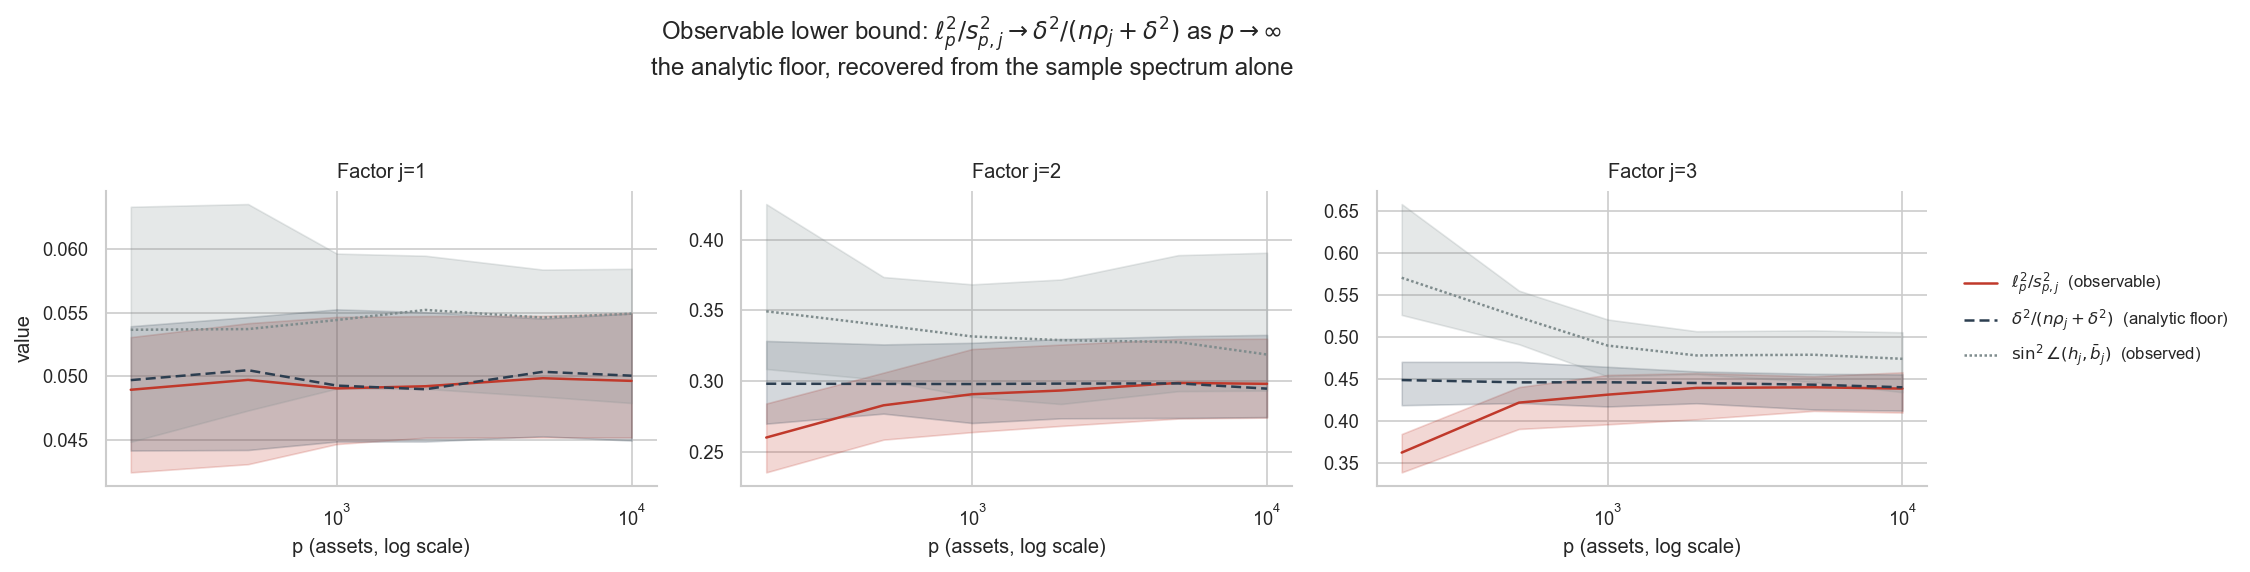

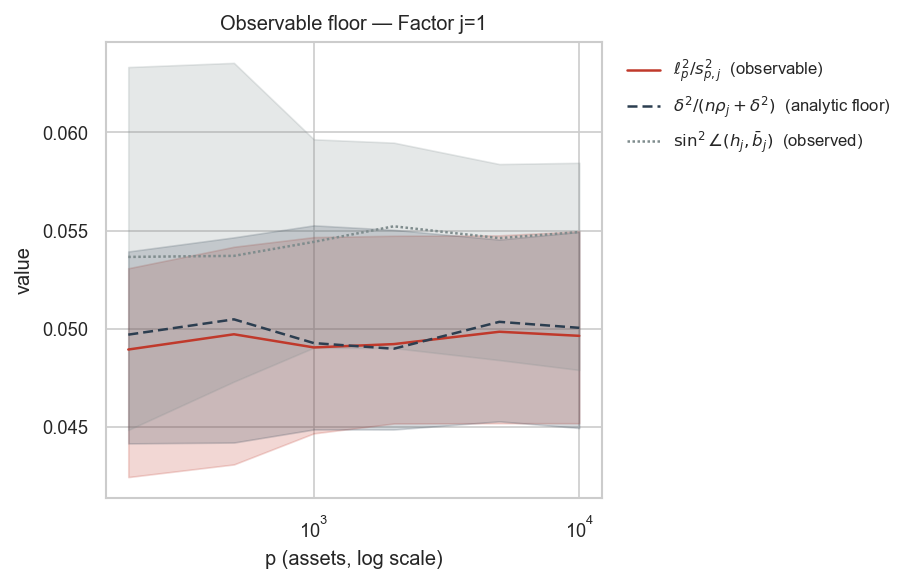

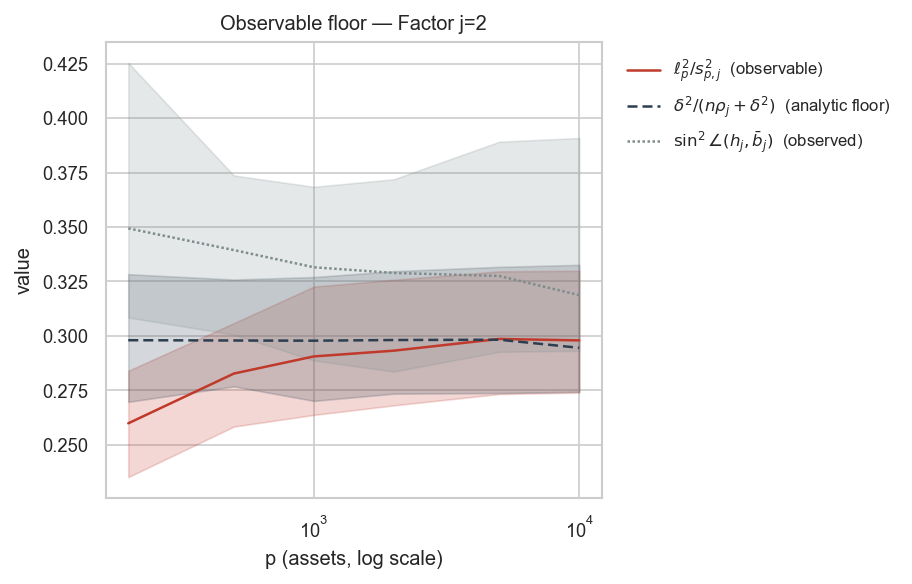

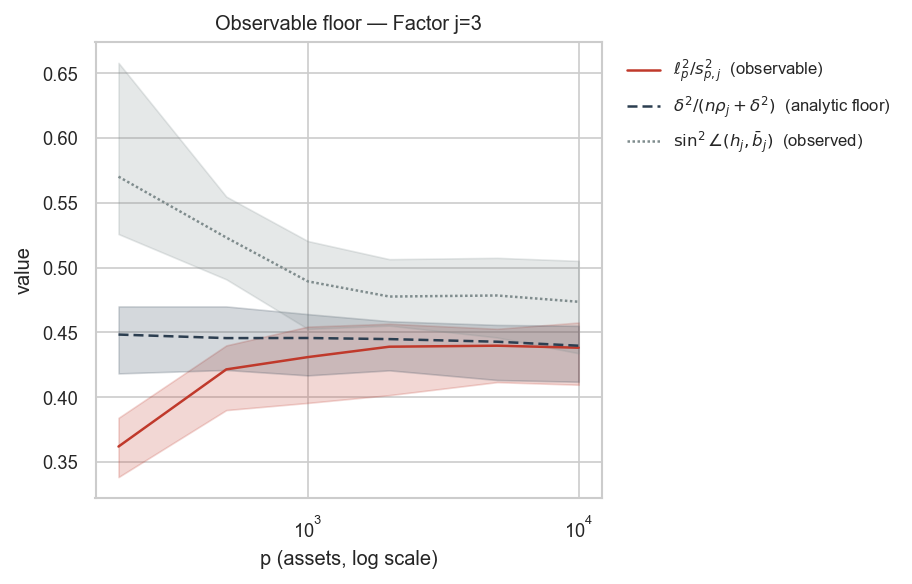

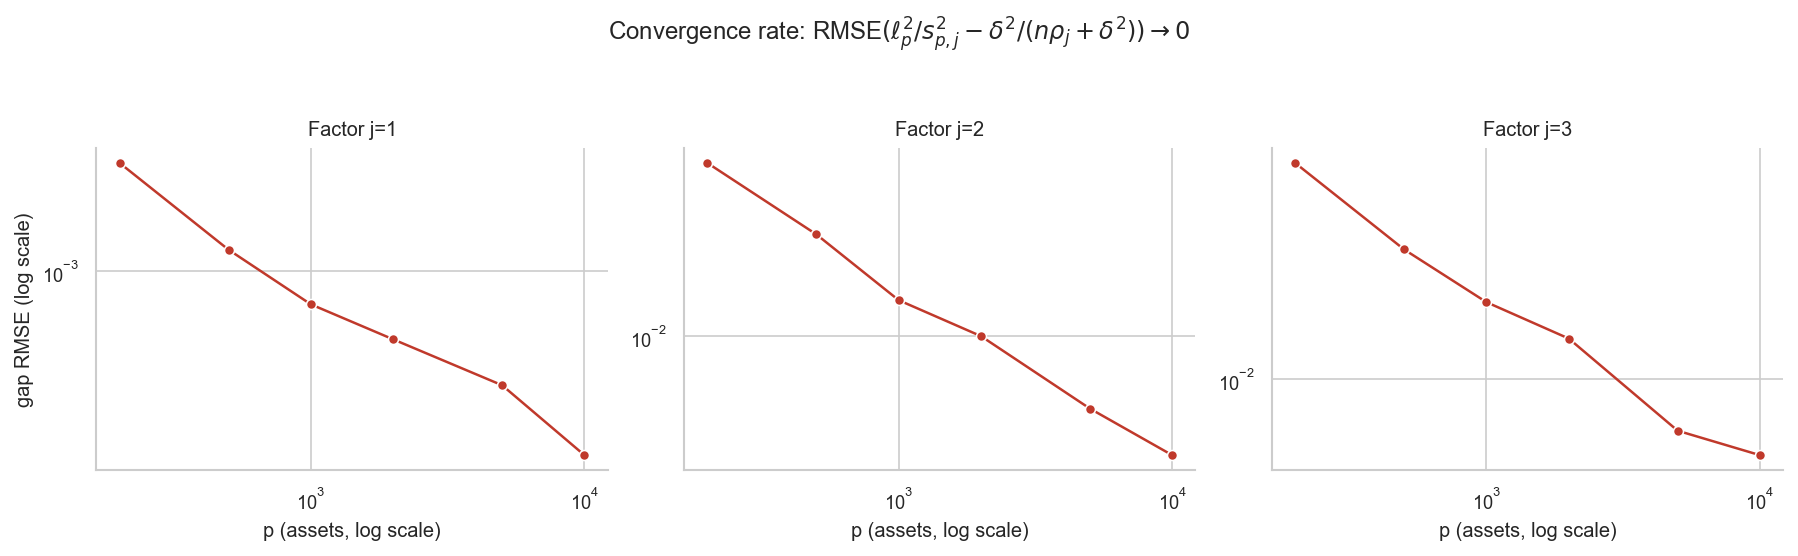

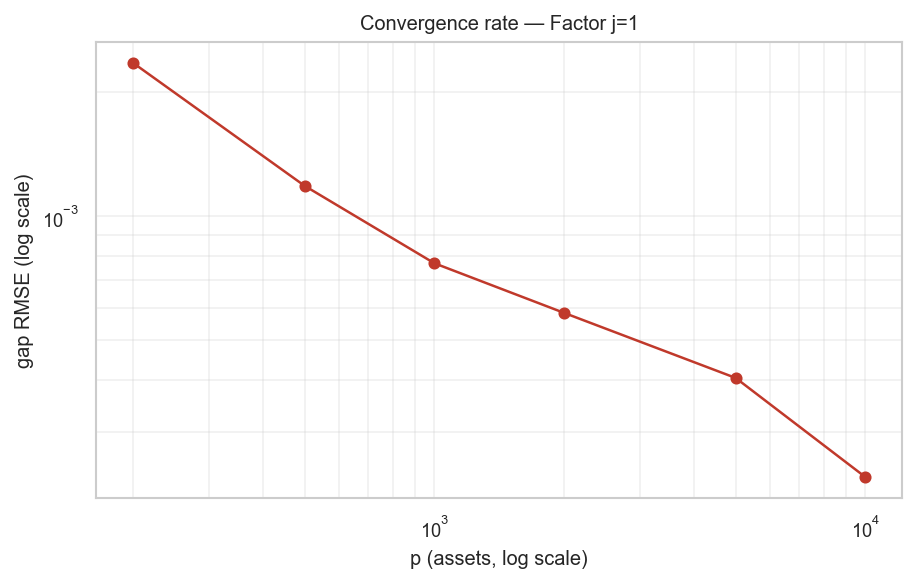

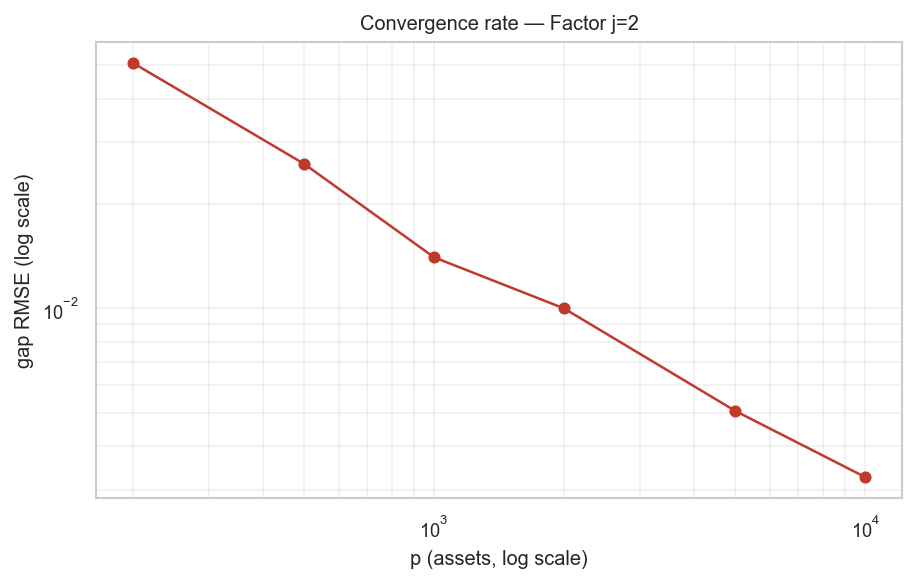

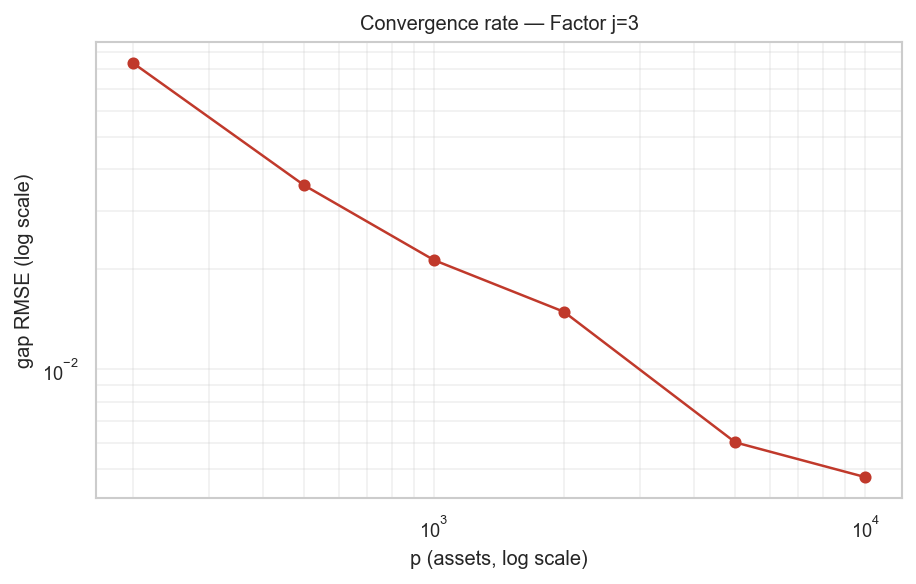

In [10]:
out_dir = Path("nb_outputs"); out_dir.mkdir(exist_ok=True)
names = (
    ["obs_floor_convergence"] + fl_graphics.OBS_FLOOR_CONVERGENCE_PER_FACTOR
    + ["obs_floor_gap"] + fl_graphics.OBS_FLOOR_GAP_PER_FACTOR
)
paths = render_figures(df, out_dir, names=names)
for name in names:                       # iterate names to guarantee order
    display(Image(str(paths[name])))

## Notes

- The proxy $\ell^2_p/s^2_{p,j}$ is **scale-invariant** in the raw dual-Gram spectrum
  $g = \mathrm{eig}(Y^\top Y)$: both $\ell^2_p$ and $s^2_{p,j}$ carry the same $1/n$ from
  the $Y/\sqrt n$ convention, which cancels in the ratio — so no covariance scaling.
- This probe is **fully standalone**: the analytic floor is inlined, with no import
  of `Eq6RHSAnalysis`. A new question is a new `Experiment`; the engine is untouched.
- To fold this into the Part (ii) components figure instead of a standalone plot,
  add `floor_obs` as a fourth series in `plot_components` — the dataframe already
  carries the column.